Powerlifting Cohort Shift - Headline Figure

William Le - 06/07/2026

Looking at whether the elite tier of raw tested powerlifting has gotten younger over the past decade. Two checks: median age of the top 50 IPF GL performers each year, and what fraction of those top 50 are Junior-age (19-23).

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from powerlifting_cohort.features import add_features, dedupe_lifter_meets
from powerlifting_cohort.bootstrap import median_age_top_n, junior_share_top_n

Matplotlib is building the font cache; this may take a moment.


Load the scoped pickle from ingest, add features, restrict to IPF weight classes, and dedupe so each lifter-meet only shows up once.

In [2]:
df = pd.read_pickle("../data/processed/openipf_scoped.pkl")
df = add_features(df)
df = df[df["is_ipf_class"]]
df = dedupe_lifter_meets(df)

print(f"{len(df):,} lifter-meets, {df['Name'].nunique():,} lifters")

539,432 lifter-meets, 212,346 lifters


For each lifter-year take the best IPF GL performance and the age at that meet. This collapses meet-level rows into a lifter-year panel.

In [3]:
ly = df.dropna(subset=["Goodlift", "Age"]).copy()
idx = ly.groupby(["Name", "Year", "Sex"])["Goodlift"].idxmax()
ly = ly.loc[idx, ["Name", "Year", "Sex", "Goodlift", "Age", "age_category"]].reset_index(drop=True)

ly.head()

,Name,Year,Sex,Goodlift,Age,age_category
0,A Ashwin,2012,M,67.32,16.5,SubJunior
1,A Belousov,2019,M,36.81,17.5,SubJunior
2,A Hemanth Kumar,2022,M,76.21,22.5,Junior
3,A K S Shri Ram,2019,M,45.30,16.0,SubJunior
4,A Madhuri,2022,F,57.72,14.5,SubJunior


Per-year median age and Junior-age share for each sex.

In [4]:
def summary_with_ci(ly, sex, years, n=50, n_boot=1000):
  rows = []
  for yr in years:
    m_pt, m_lo, m_hi = median_age_top_n(ly, sex, yr, n=n, n_boot=n_boot)
    j_pt, j_lo, j_hi = junior_share_top_n(ly, sex, yr, n=n, n_boot=n_boot)
    rows.append({
        "Year": yr,
        "median_age": m_pt, "age_lo": m_lo, "age_hi": m_hi,
        "junior_frac": j_pt, "jr_lo": j_lo, "jr_hi": j_hi
    })
  return pd.DataFrame(rows)

years = list(range(2014, 2026))
sm = summary_with_ci(ly, "M", years)
sf = summary_with_ci(ly, "F", years)

print("Men:")
print(sm.to_string(index=False))
print()
print("Women:")
print(sf.to_string(index=False))

Men:
 Year  median_age  age_lo  age_hi  junior_frac  jr_lo  jr_hi
 2014       28.00   26.50   30.50         0.20   0.08   0.32
 2015       28.75   27.25   32.75         0.14   0.04   0.26
 2016       28.00   26.25   29.75         0.20   0.10   0.32
 2017       28.00   26.00   29.00         0.24   0.12   0.36
 2018       27.75   25.00   30.25         0.24   0.14   0.38
 2019       26.75   25.25   28.50         0.30   0.16   0.42
 2020       26.50   25.00   27.50         0.22   0.10   0.34
 2021       26.00   25.00   27.00         0.14   0.06   0.26
 2022       27.00   25.25   29.00         0.24   0.12   0.36
 2023       26.50   26.00   29.00         0.18   0.08   0.30
 2024       27.00   26.50   28.75         0.10   0.02   0.20
 2025       26.00   25.00   28.00         0.30   0.16   0.42

Women:
 Year  median_age  age_lo   age_hi  junior_frac  jr_lo  jr_hi
 2014       32.25 27.5000 34.00000         0.14   0.06 0.2600
 2015       31.50 28.5000 34.00625         0.18   0.08 0.2800
 2016   

Both panels in one figure - left is median age, right is Junior-age share.

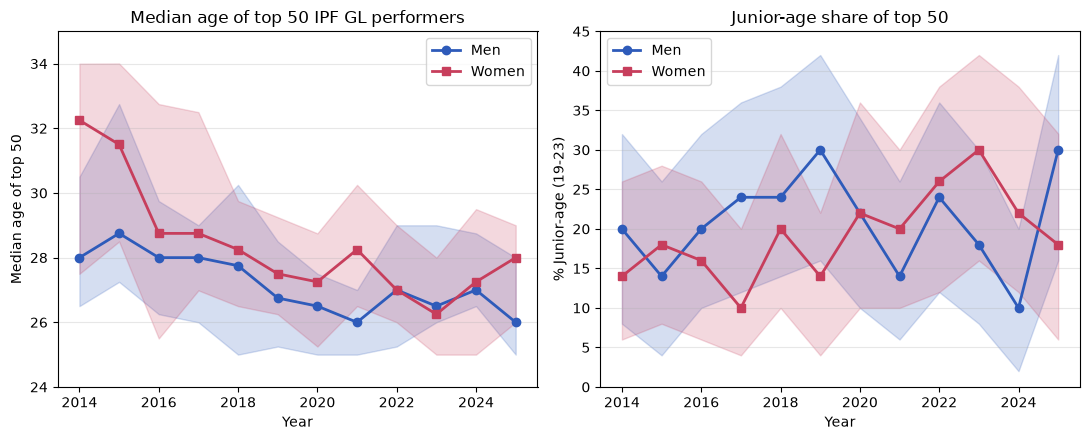

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(sm["Year"], sm["median_age"], "o-", color="#2E5BBA", linewidth=2, label="Men")
ax1.fill_between(sm["Year"], sm["age_lo"], sm["age_hi"], color="#2E5BBA", alpha=0.2)
ax1.plot(sf["Year"], sf["median_age"], "s-", color="#C73E5C", linewidth=2, label="Women")
ax1.fill_between(sf["Year"], sf["age_lo"], sf["age_hi"], color="#C73E5C", alpha=0.2)
ax1.set_xlabel("Year")
ax1.set_ylabel("Median age of top 50")
ax1.set_title("Median age of top 50 IPF GL performers")
ax1.set_ylim(24, 35)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

ax2.plot(sm["Year"], sm["junior_frac"]*100, "o-", color="#2E5BBA", linewidth=2, label="Men")
ax2.fill_between(sm["Year"], sm["jr_lo"]*100, sm["jr_hi"]*100, color="#2E5BBA", alpha=0.2)
ax2.plot(sf["Year"], sf["junior_frac"]*100, "s-", color="#C73E5C", linewidth=2, label="Women")
ax2.fill_between(sf["Year"], sf["jr_lo"]*100, sf["jr_hi"]*100, color="#C73E5C", alpha=0.2)
ax2.set_xlabel("Year")
ax2.set_ylabel("% Junior-age (19-23)")
ax2.set_title("Junior-age share of top 50")
ax2.set_ylim(0, 45)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/01_headline.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
from powerlifting_cohort.bootstrap import median_age_diff

for sex in ["M", "F"]:
  pt, lo, hi = median_age_diff(ly, sex, 2014, 2025)
  print(f"{sex} median age 2025 minus 2014: {pt:.2f} [{lo:.2f}, {hi:.2f}]")

M median age 2025 minus 2014: -2.00 [-5.00, 0.75]
F median age 2025 minus 2014: -4.25 [-7.00, 0.50]


In [7]:
from powerlifting_cohort.bootstrap import median_age_diff_pooled

for sex in ["M", "F"]:
  pt, lo, hi = median_age_diff_pooled(ly, sex, [2014, 2015, 2016, 2017], [2022, 2023, 2024, 2025])
  print(f"{sex} pooled median age (2022-25) - (2014-17): {pt:.2f} [{lo:.2f}, {hi:.2f}]")

M pooled median age (2022-25) - (2014-17): -1.56 [-2.81, -0.06]
F pooled median age (2022-25) - (2014-17): -3.19 [-4.88, -1.38]


Median age dropped 2 years for men (28 -> 26) and 5 years for women (32 -> 27) over 2014-2025. Women's drop is sharper and happens mostly in 2015-2016. Junior-age share roughly doubled for both.